In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error

In [6]:

df = pd.read_csv('student.csv')
print(df.head())
print(df.info())

     branch college_tier  cgpa  backlogs  coding_skills  dsa_score  \
0       ECE       Tier-3  6.70         0            7.6        4.4   
1  Chemical       Tier-2  5.70         0            5.4        7.9   
2        EE       Tier-2  7.19         0            5.6        6.8   
3        CE       Tier-2  6.48         0            5.2        3.1   
4       CSE       Tier-2  6.71         1            5.9        4.7   

   aptitude_score  communication_skills  ml_knowledge  system_design  \
0            49.5                   3.7           6.4            0.3   
1            72.0                   8.3           6.3            1.9   
2            79.1                   7.4           4.4            5.2   
3            48.4                   5.0           1.1            6.7   
4            61.2                   4.3           2.7            2.8   

   internships  projects_count  certifications  hackathons  \
0            1               4               4           3   
1            0        

                cgpa       backlogs  coding_skills      dsa_score  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean        7.206381       0.547010       5.995147       5.500711   
std         0.925235       0.862727       1.496302       1.781961   
min         4.000000       0.000000       1.000000       1.000000   
25%         6.580000       0.000000       5.000000       4.300000   
50%         7.210000       0.000000       6.000000       5.500000   
75%         7.830000       1.000000       7.000000       6.700000   
max        10.000000       3.000000      10.000000      10.000000   

       aptitude_score  communication_skills   ml_knowledge  system_design  \
count   100000.000000         100000.000000  100000.000000  100000.000000   
mean        64.990511              5.990614       4.508752       4.008210   
std         11.990892              1.496552       1.968278       1.778405   
min         20.000000              1.000000       0.000000       0.000

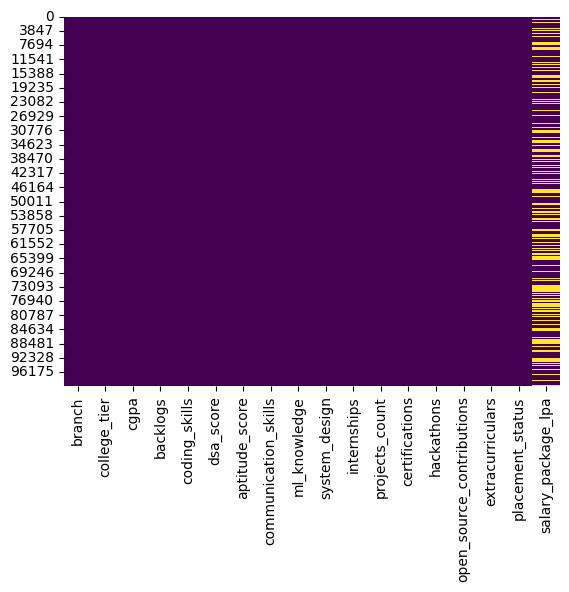

In [7]:

print(df.describe())
print(df.isnull().sum())

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [8]:

numerical_cols = df.select_dtypes(include=[np.number]).columns
imputer_num = SimpleImputer(strategy='mean')
df[numerical_cols] = imputer_num.fit_transform(df[numerical_cols])


categorical_cols = df.select_dtypes(include=[object]).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = imputer_cat.fit_transform(df[categorical_cols])

print(df.isnull().sum())

branch                       0
college_tier                 0
cgpa                         0
backlogs                     0
coding_skills                0
dsa_score                    0
aptitude_score               0
communication_skills         0
ml_knowledge                 0
system_design                0
internships                  0
projects_count               0
certifications               0
hackathons                   0
open_source_contributions    0
extracurriculars             0
placement_status             0
salary_package_lpa           0
dtype: int64


In [9]:

le = LabelEncoder()
df['branch'] = le.fit_transform(df['branch'])
df['college_tier'] = le.fit_transform(df['college_tier'])


print(df.head())

   branch  college_tier  cgpa  backlogs  coding_skills  dsa_score  \
0       3             2  6.70       0.0            7.6        4.4   
1       2             1  5.70       0.0            5.4        7.9   
2       4             1  7.19       0.0            5.6        6.8   
3       0             1  6.48       0.0            5.2        3.1   
4       1             1  6.71       1.0            5.9        4.7   

   aptitude_score  communication_skills  ml_knowledge  system_design  \
0            49.5                   3.7           6.4            0.3   
1            72.0                   8.3           6.3            1.9   
2            79.1                   7.4           4.4            5.2   
3            48.4                   5.0           1.1            6.7   
4            61.2                   4.3           2.7            2.8   

   internships  projects_count  certifications  hackathons  \
0          1.0             4.0             4.0         3.0   
1          0.0             4

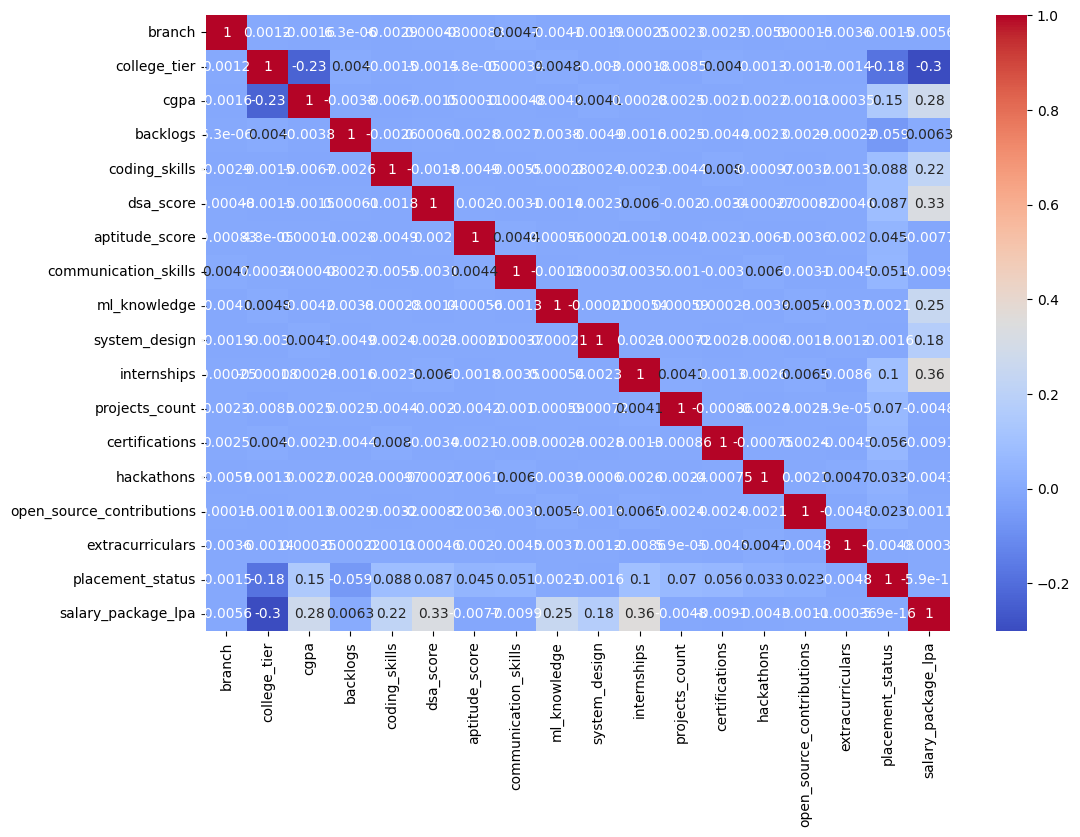

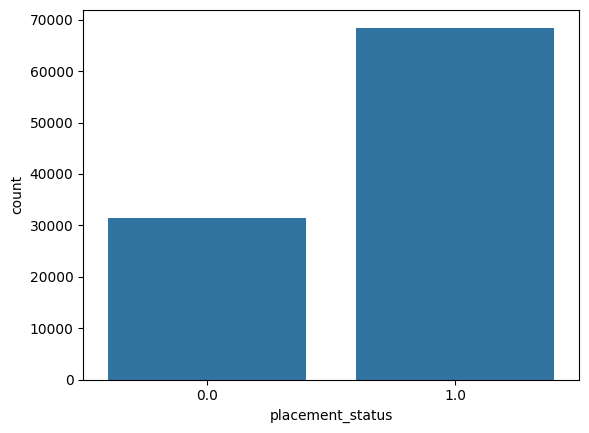

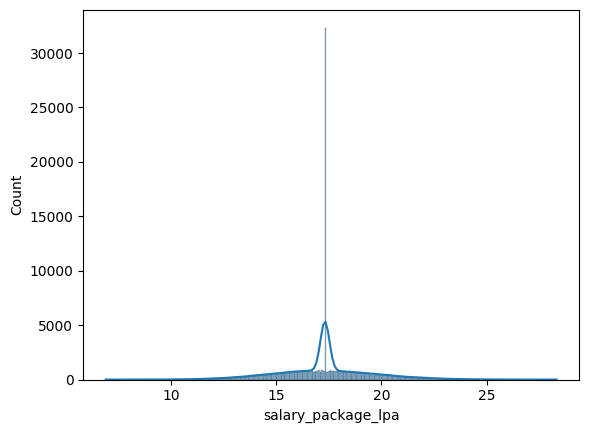

In [10]:

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


sns.countplot(x='placement_status', data=df)
plt.show()


sns.histplot(df['salary_package_lpa'], kde=True)
plt.show()

In [11]:

X = df.drop(['placement_status', 'salary_package_lpa'], axis=1)
y = df['placement_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.69395


In [12]:

df_placed = df[df['placement_status'] == 1]
X_salary = df_placed.drop(['placement_status', 'salary_package_lpa'], axis=1)
y_salary = df_placed['salary_package_lpa']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_salary, y_salary, test_size=0.2, random_state=42)

X_train_s_scaled = scaler.fit_transform(X_train_s)
X_test_s_scaled = scaler.transform(X_test_s)

reg_model = LinearRegression()
reg_model.fit(X_train_s_scaled, y_train_s)

y_pred_s = reg_model.predict(X_test_s_scaled)
print('MSE:', mean_squared_error(y_test_s, y_pred_s))

MSE: 1.5262808787211006


In [13]:

import joblib

joblib.dump(model, 'placement_model.joblib')
joblib.dump(reg_model, 'salary_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(le, 'label_encoder.joblib')

print('Models saved successfully!')

Models saved successfully!
